In [1]:
"""
Plot the scattering cross section for 1 micron water droplets.

The plot shows the cross section as a function of wavelength.
"""

import numpy as np
import matplotlib.pyplot as plt
import miepython as mie
from scipy.special import erfc
import scattering_funcs as sf
import noise_impact_funcs as nf
import pandas as pd
import math
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
#Load refractive index data.
#Segelstein data for water, wavelength in µm. [wavelength, n, k], where complex refractive index is m = n + ik.
ref_index_data = np.loadtxt(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\H20_Segelstein.txt", skiprows=13, delimiter=None,comments="#")

#Verify the data looks correct
# plt.plot(ref_index_data[:,0], ref_index_data[:,1], label="n")
# plt.plot(ref_index_data[:,0], ref_index_data[:,2], label="k")
# plt.xscale("log")
# plt.grid()
# plt.ylim(0,10)

#Truncate to match Grillot paper
i_start = np.min(np.where(ref_index_data[:,0] >= 0.1)) #0.1µm wavelength start
i_end = np.max(np.where(ref_index_data[:,0] <= 20)) #20µm wavelength end

ref_index_data_trunc = ref_index_data[i_start:i_end]

wavelengths = ref_index_data_trunc[:,0]
n_values = ref_index_data_trunc[:,1]
k_values = ref_index_data_trunc[:,2]

m = n_values + 1j * k_values #complex refractive index used for Mie scattering

index_550nm = np.abs(wavelengths-0.55).argmin() #Find index for 550nm
index_1550 =np.abs(wavelengths-1.55).argmin() #Find index for 1550nm
index_4000 =np.abs(wavelengths-4.00).argmin() #Find index for 4000nm
index_10000 =np.abs(wavelengths-10.2).argmin() #Find index for 10200nm

#index_11450 =np.abs(wavelengths-11.45).argmin() #Find index for 10200nm


decimals = 2

wav_FSO_index = [index_1550, index_4000, index_10000]#,index_11450]
lambda0s = wavelengths[wav_FSO_index]

lambda0_labels = [f"{wl:.{decimals}f} µm" for wl in lambda0s]



In [3]:
#Calculate the Mie scattering cross-sections (coefficients) for a range of droplet sizes (used in Grillot paper) and wavelengths from 0.1µm to 20µm spacing from Segelstein data.

radius = np.linspace(0.01, 50, 1000)  # in microns

geometric_cross_section = np.pi * radius**2

q_ext = [0]*len(wavelengths)
q_sca = q_ext.copy()
q_abs = q_ext.copy()
q_back = q_ext.copy()
g = q_ext.copy()

for i,lambda0 in enumerate(wavelengths):
   
    q_ext[i], q_sca[i], q_back[i], g[i] = mie.efficiencies(m[i], 2 * radius, lambda0)
    q_abs[i] = q_ext[i] - q_sca[i]



In [4]:
fog_data = sf.load_fog_data(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Radiation_fog_data.xlsx") #From C. Klein and A. Dabas, 2014

fog_data_adv = sf.load_adv_fog_data(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Adv_fog_data.xlsx") #From M. Sizun, 2003

for fog in fog_data_adv:
    fog_data.append(fog)

list_DSDs =[0]*len(fog_data)

for i,fog in enumerate(fog_data):
    
    if i < (len(fog_data)-len(fog_data_adv)):
        list_DSDs[i] = sf.log_normal_modes(fog["N_k"], fog["sigma_k"], fog["r_k"],radius)
    else:
        list_DSDs[i] = sf.mod_gamma_dist(fog['a'],fog['B'],fog['alpha'],radius)

    fog_data[i]["DSD"]=list_DSDs[i]
 

In [5]:
#Calculate the Mie extinction coefficients using the DSDs. Essentially integrating over DSD times pi*r^2*Q_k, where Q_k is the Mie efficiency for extinction, scattering or absorption.
#Also plotting the DSDs


dsd_map = {f"Fog {dic['n']}": dic["DSD"] for dic in fog_data}
eff_map = {"extinction": q_ext, "scattering": q_sca, "absorption": q_abs}


coefficients = {}
for dsd_label, dsd in dsd_map.items():
    for eff_label, q_values in eff_map.items(): #For each Mie cross-section, Q_k (which is a list of 755 wavelength input and inside has 1000 radius input)
        row_label = f"{dsd_label} {eff_label}"
        
        #For each wavelength, Fog (DSD)  and Q_k[wavelength], calculate the extinction value by integrating over radii:
        coefficients[row_label] = [
            sf.mie_extinction_coefficient(dsd, q_values[i], radius) #For the DSD type, we calculate a list of extinction coefficients (attenuation) for each Mie cross section list (at the specific wavelength) which corresponds to the extinction value for the wavelength. Where we have integrated over all radii values to obtain the final extinction coefficient for each wavelength. 
            for i in range(len(wavelengths)) #So we get a list for each row label. We have an extinction value for each of the 755 wavelengths we look at. 
        ]

df = pd.DataFrame(coefficients, index=[f"{wl:.{decimals}f} µm" for wl in wavelengths]).T
# print(df[lambda0_labels])



In [6]:
def format_vis(x):
    if x >= 10:
        return f"{x:.0f}"
    elif x >= 1:
        return f"{x:.0f}"
    elif x >=0.5:
        return f"{x:.1f}"  
    else:
        return f"{x:.2f}" 


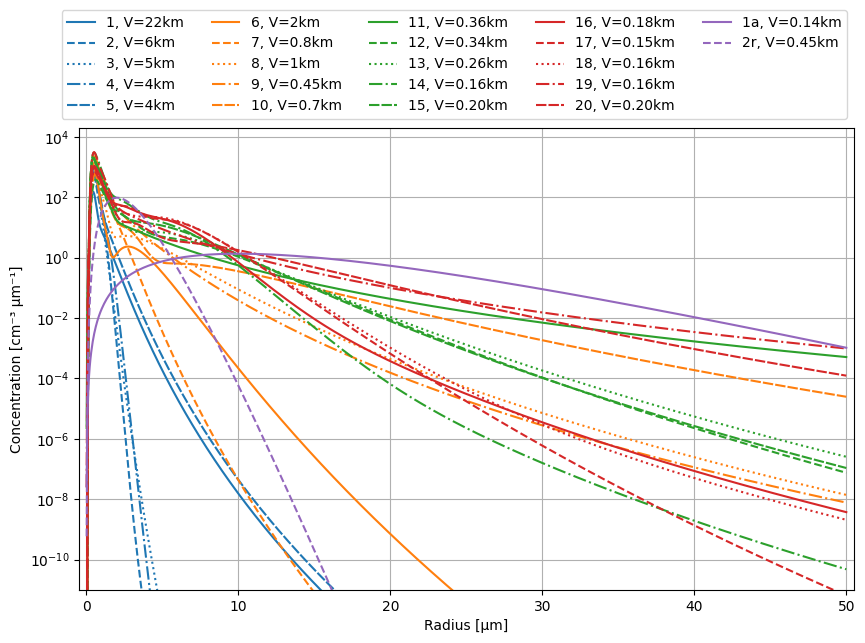

In [7]:
#Plot the DSDs

fog_labels = list(dsd_map.keys())
eff_labels = list(eff_map.keys())


visibilities = [0]*len(fog_data)

contrast_thres = -np.log(0.02)



line_styles = ['-', '--', ':', '-.', (0, (5, 1))]  # solid, dashed, dotted, dashdot, dense-dash

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default matplotlib palette



plt.figure(figsize=(10,6))
for i,fog in enumerate(fog_data):

    beta_550 = df.loc[fog_labels[i] + ' ' + eff_labels[0]].values[index_550nm]

    
    style = line_styles[i % 5]
    color = colors[(i // 5) % len(colors)]


    visibilities[i] = contrast_thres / beta_550

    fog_data[i]['Visibility [km]'] = visibilities[i]


    plt.plot(radius, fog["DSD"], color=color, linestyle=style, label=f'{fog_data[i]['n']}, V={format_vis(visibilities[i])}km')
    

plt.yscale("log")
plt.yticks([10**i for i in range(-10, 5, 2)])
plt.ylim(1e-11,2e4)
plt.xlim(-0.5,50.5)
plt.grid(which="major")
plt.xlabel("Radius [µm]")
plt.ylabel("Concentration [cm⁻³ µm⁻¹]")


n_col=5
handles,labels = plt.gca().get_legend_handles_labels()

n_entries = len(handles)
n_row = math.ceil(n_entries/n_col)
n_blank_handle = n_row*n_col - n_entries
blank_handle = Patch(visible=False)

for i in range(n_blank_handle):
    handles.append(blank_handle)
    labels.append("")

plt.legend(handles,labels,ncol=n_col,bbox_to_anchor=[1,1.27])

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\DSD_various_fogs.svg", bbox_inches='tight')
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\DSD_various_fogs.pdf", bbox_inches='tight')


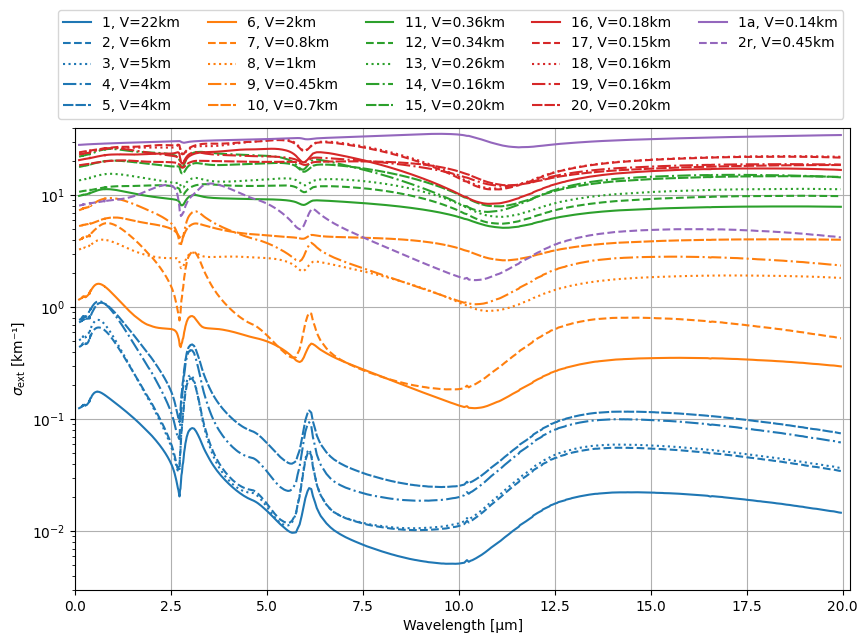

In [8]:
#Plot the Mie extinction coefficients using the DSDs.


coefficients = {}
for dsd_label, dsd in dsd_map.items():
    for eff_label, q_values in eff_map.items(): #For each Mie cross-section, Q_k (which is a list of 755 wavelength input and inside has 1000 radius input)
        row_label = f"{dsd_label} {eff_label}"
        
        #For each wavelength, Fog (DSD)  and Q_k[wavelength], calculate the extinction value by integrating over radii:
        coefficients[row_label] = [
            sf.mie_extinction_coefficient(dsd, q_values[i], radius) #For the DSD type, we calculate a list of extinction coefficients (attenuation) for each Mie cross section list (at the specific wavelength) which corresponds to the extinction value for the wavelength. Where we have integrated over all radii values to obtain the final extinction coefficient for each wavelength. 
            for i in range(len(wavelengths)) #So we get a list for each row label. We have an extinction value for each of the 755 wavelengths we look at. 
        ]

df = pd.DataFrame(coefficients, index=[f"{wl:.{decimals}f} µm" for wl in wavelengths]).T
# print(df[lambda0_labels])

plt.figure(figsize=(10,6)) 





for i,label in enumerate(fog_labels):


    
    style = line_styles[i % 5]
    color = colors[(i // 5) % len(colors)]



    plt.plot(wavelengths, df.loc[label + ' ' + eff_labels[0]].values, linestyle=style, color=color ,label=f'{fog_data[i]['n']}, V={format_vis(visibilities[i])}km')

plt.grid()
plt.legend()
plt.xlabel("Wavelength [µm]")
plt.ylabel(r"$\sigma_\mathrm{ext}$ [km⁻¹]")

plt.yscale('log')
plt.ylim(3e-3,40)
plt.xlim(0,20.2)

n_col=5
handles,labels = plt.gca().get_legend_handles_labels()

n_entries = len(handles)
n_row = math.ceil(n_entries/n_col)
n_blank_handle = n_row*n_col - n_entries
blank_handle = Patch(visible=False)

for i in range(n_blank_handle):
    handles.append(blank_handle)
    labels.append("")

plt.legend(handles,labels,ncol=n_col,bbox_to_anchor=[1,1.27])



plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Extinction_coefficient_Mie_various_fogs.svg",bbox_inches='tight')
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Extinction_coefficient_Mie_various_fogs.pdf",bbox_inches='tight')



In [9]:
# a = [-1.4,-1.9,-2.2]
# b = [2,0.9,0.3]
# c = [0.08,0.018,0.005]

# x = np.linspace(min(visibilities),max(visibilities),100)

# for i in range(len(wav_FSO_index)):

#     extinction = df.loc[df.index.str.contains("extinction", case=False),lambda0_labels[i]].values

#     line = plt.plot(visibilities,extinction,'.', label = lambda0_labels[i])
#     plt.plot(x,b[i]*x**a[i]+c[i],'--', alpha=0.5, label = lambda0_labels[i]+', pol.',color = line[0].get_color())

# plt.legend()
# plt.xlabel('Visibility [km]')
# plt.ylabel(r'$\sigma_\mathrm{ext}$ [km$^{-1}$]')
# plt.yscale('log')
# plt.xscale('log')
# plt.grid()


# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Attenuation_coefficient_Mie_vs_visibility.svg")
# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Attenuation_coefficient_Mie_vs_visibility.pdf")


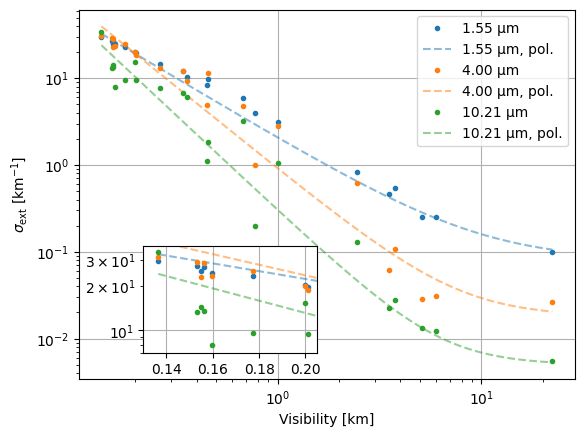

In [10]:
a = [-1.4, -1.9, -2.2,-1.95]
b = [2, 0.9, 0.3,0.4]
c = [0.08, 0.018, 0.005, 0.01]

x = np.linspace(min(visibilities), max(visibilities), 100)

fig, ax = plt.subplots()

for i in range(len(wav_FSO_index)):
    extinction = df.loc[
        df.index.str.contains("extinction", case=False),
        lambda0_labels[i]
    ].values

    line = ax.plot(visibilities, extinction, '.', label=lambda0_labels[i])
    ax.plot(
        x,
        b[i] * x**a[i] + c[i],
        '--',
        alpha=0.5,
        label=lambda0_labels[i] + ', pol.',
        color=line[0].get_color()
    )

# Main plot formatting
ax.legend()
ax.set_xlabel('Visibility [km]')
ax.set_ylabel(r'$\sigma_\mathrm{ext}$ [km$^{-1}$]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()

# ---- Inset ----

axins = inset_axes(
    ax,
    width="100%", height="100%",  # full size of the bbox
    bbox_to_anchor=(0.13, 0.07, 0.35, 0.29),  # (x0, y0, w, h) in axes coords
    bbox_transform=ax.transAxes,
    borderpad=0
)


for i in range(len(wav_FSO_index)):
    extinction = df.loc[
        df.index.str.contains("extinction", case=False),
        lambda0_labels[i]
    ].values

    axins.plot(visibilities, extinction, '.', color=ax.lines[2*i].get_color())
    axins.plot(
        x,
        b[i] * x**a[i] + c[i],
        '--',
        alpha=0.5,
        color=ax.lines[2*i].get_color()
    )

# Zoom region
axins.set_xlim(0.13, 0.205)
axins.set_ylim(7, 37)

axins.set_yscale('log')

axins.grid()

plt.show()


fig.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Attenuation_coefficient_Mie_vs_visibility.svg")
fig.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Attenuation_coefficient_Mie_vs_visibility.pdf")

In [11]:
#Comparisons of different FSO optical links using directly modulated sources. We assume detection is limited by thermal noise (Johnson-noise-limited detection)
#ICL 4µm, power: 100mW, 


#QCL: 10µm, power: 0.1W OOK:15Gbps, PAM4: 16.9 Gbps
#1550nm + EDFA: 1.55µm, 1W, OOK:100 Gbps, PAM4: 40 Gbps


QCL_power = 0.00963 #W - 9.63 mW
QCL_wl = 9.1 #µm

QCL_data_rate_OOK = 15e9
QCL_data_rate_PAM4 = 16.9e9

ICL_power = 0.005 #W - 5 mW
ICL_wl = 4.18 #µm
ICL_data_rate_OOK = 12e9
ICL_data_rate_PAM4 = 14e9


DFB_power = 1 #10**(11/10-3) gives 11dBm, 12 mW, 0.012, but we add EDFA: 1W. For more power from EDFA, we also boost spontaneous emission, so SNR may suffer, but negligible at 1W
DFB_wl = 1.55 #µm
DFB_data_rate_OOK = 20e9 #20 Gbps
DFB_data_rate_PAM = 40e9 #40 Gbps

QV_power = 0.02 #W - 20mW
QV_wl_LWIR = 10.2 #µm
QV_wl_MWIR = 4.18 #µm

QV_wl_LWIR2= 11.45 #µm



NEP_SWIR = 16e-12 #W/Hz^0.5
NEP_MWIR = 2.83e-9 #W/Hz^0.5
NEP_LWIR = 2.36e-9 #W/Hz^0.5

#M. Joharifar, et al., 2024:
QCL_OOK = {'type':'QCL', 'power': QCL_power, 'wavelength':QCL_wl, 'scheme':'OOK', 'data rate':QCL_data_rate_OOK, 'dect type':'LWIR', 'NEP':NEP_LWIR, } #1m distance
QCL_PAM4 = {'type':'QCL', 'power': QCL_power, 'wavelength':QCL_wl, 'scheme':'PAM4', 'data rate':QCL_data_rate_PAM4, 'dect type':'LWIR', 'NEP':NEP_LWIR} #1m distance

#P. Didier, et al., 2023:
ICL_OOK = {'type':'ICL', 'power': ICL_power, 'wavelength':ICL_wl, 'scheme':'OOK', 'data rate':ICL_data_rate_OOK, 'dect type':'MWIR', 'NEP':NEP_MWIR} #2m distance
ICL_PAM4 = {'type':'ICL', 'power': ICL_power, 'wavelength':ICL_wl, 'scheme':'PAM4', 'data rate':ICL_data_rate_PAM4, 'dect type':'MWIR', 'NEP':NEP_MWIR} #2m distance

#G Nazarikov, et al., 2024: (NRZ-OOK used here)
DFB_OOK = {'type':'DFB', 'power': DFB_power, 'wavelength':DFB_wl, 'scheme':'OOK', 'data rate':DFB_data_rate_OOK, 'dect type':'SWIR', 'NEP':NEP_SWIR} 
DFB_PAM4 = {'type':'DFB', 'power': DFB_power, 'wavelength':DFB_wl, 'scheme':'PAM4', 'data rate':DFB_data_rate_PAM, 'dect type':'SWIR', 'NEP':NEP_SWIR} #10 km fiber distance


#Source: Mikkel
QV_OOK_LWIR_conv = {'type':'QV LWIR conv', 'power': QV_power, 'wavelength':QV_wl_LWIR, 'scheme':'OOK', 'data rate':DFB_data_rate_OOK, 'dect type':'conversion', 'NEP':NEP_SWIR} #Using data rate for telecom
QV_PAM4_LWIR_conv = {'type':'QV LWIR conv', 'power': QV_power, 'wavelength':QV_wl_LWIR, 'scheme':'PAM4', 'data rate':DFB_data_rate_PAM, 'dect type':'conversion', 'NEP':NEP_SWIR} #Using data rate for telecom

QV_OOK_LWIR = {'type':'QV LWIR', 'power': QV_power, 'wavelength':QV_wl_LWIR, 'scheme':'OOK', 'data rate':DFB_data_rate_OOK, 'dect type':'LWIR', 'NEP':NEP_LWIR} 
QV_PAM4_LWIR = {'type':'QV LWIR', 'power': QV_power, 'wavelength':QV_wl_LWIR, 'scheme':'PAM4', 'data rate':DFB_data_rate_PAM, 'dect type':'LWIR', 'NEP':NEP_LWIR} 


QV_OOK_MWIR_conv = {'type':'QV MWIR conv', 'power': QV_power, 'wavelength':QV_wl_MWIR, 'scheme':'OOK', 'data rate':DFB_data_rate_OOK, 'dect type':'conversion', 'NEP':NEP_SWIR} #Using data rate for telecom
QV_PAM4_MWIR_conv = {'type':'QV MWIR conv', 'power': QV_power, 'wavelength':QV_wl_MWIR, 'scheme':'PAM4', 'data rate':DFB_data_rate_PAM, 'dect type':'conversion', 'NEP':NEP_SWIR} #Using data rate for telecom

QV_OOK_MWIR = {'type':'QV MWIR', 'power': QV_power, 'wavelength':QV_wl_MWIR, 'scheme':'OOK', 'data rate':DFB_data_rate_OOK, 'dect type':'LWIR', 'NEP':NEP_MWIR} 
QV_PAM4_MWIR = {'type':'QV MWIR', 'power': QV_power, 'wavelength':QV_wl_MWIR, 'scheme':'PAM4', 'data rate':DFB_data_rate_PAM, 'dect type':'LWIR', 'NEP':NEP_MWIR} 

# QV_OOK_LWIR_conv2 = {'type':'QV 11.46µm conv', 'power': QV_power, 'wavelength':QV_wl_LWIR2, 'scheme':'OOK', 'data rate':DFB_data_rate_OOK, 'dect type':'conversion', 'NEP':NEP_SWIR} #Using data rate for telecom
# QV_PAM4_LWIR_conv2 = {'type':'QV 11.46µm conv', 'power': QV_power, 'wavelength':QV_wl_LWIR2, 'scheme':'PAM4', 'data rate':DFB_data_rate_PAM, 'dect type':'conversion', 'NEP':NEP_SWIR} #Using data rate for telecom

# QV_OOK_LWIR2 = {'type':'QV 11.46µm', 'power': QV_power, 'wavelength':QV_wl_LWIR2, 'scheme':'OOK', 'data rate':DFB_data_rate_OOK, 'dect type':'LWIR', 'NEP':NEP_LWIR} 
# QV_PAM4_LWIR2 = {'type':'QV 11.46µm', 'power': QV_power, 'wavelength':QV_wl_LWIR2, 'scheme':'PAM4', 'data rate':DFB_data_rate_PAM, 'dect type':'LWIR', 'NEP':NEP_LWIR} 


com_schemes_list = [QCL_OOK, QCL_PAM4, ICL_OOK, ICL_PAM4, DFB_OOK, DFB_PAM4, QV_OOK_LWIR_conv, QV_PAM4_LWIR_conv, QV_OOK_LWIR, QV_PAM4_LWIR, QV_OOK_MWIR_conv, QV_PAM4_MWIR_conv, QV_OOK_MWIR, QV_PAM4_MWIR] #, QV_OOK_LWIR_conv2, QV_PAM4_LWIR_conv2, QV_OOK_LWIR2, QV_PAM4_LWIR2]


In [12]:
#Calculate attenuation dependent on distance

distance = np.logspace(-3,3,1000) #1m to 1000km

for com in com_schemes_list:

    com['wl index'] = np.abs(wavelengths-com['wavelength']).argmin() #Find index for wavelength closest to wavelengths from papers
    index = com['wl index']
    com['wavelength'] = wavelengths[com['wl index']] #Update wavelengths

    attenuation_coef_list = [df.loc[label + ' ' + eff_labels[0]].values[index] for label in fog_labels] #For each fog, extract the (total extinction) attenuation coefficient for the given wavelength in the communication scheme

    com['attenuation coef list'] = attenuation_coef_list

    attenuation_lin = [[sf.Beers_law(1, attenuation_coef, dist)[0] for dist in distance] for attenuation_coef in attenuation_coef_list] #Using 1 as power so keeping attenuation independent of power output of laser. Multiply on actual power output to get real number

    com['attenuation factor lin'] = attenuation_lin #22 lists, one for each fog, containing attenuation factor values for each distance



c:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\PICLab_narrow_linewidth\Mid-IR\scattering_funcs.py:107: RuntimeWarning: divide by zero encountered in log10
  power_dB = 10 * np.log10(power_out/power_input)


In [13]:
FEC_thres = 3.8e-3 # forward-error correction threshold

for com in com_schemes_list:

    bw = com['data rate']/2 #bandwidth corresponds to half

    if com['dect type'] == 'conversion': #Assuming losing half the power during conversion before detection
        power = com['power']/2
    else:
        power = com['power']

    noise_dec = nf.detector_noise(com['NEP'], bw)

    com['dec noise'] = noise_dec

    SNR_list = [[nf.signal_to_noise_ratio(power, attenuation_dist, noise_dec) for attenuation_dist in attenuation_dist_list] for attenuation_dist_list in com['attenuation factor lin']] #Calculate SNR as list for each distance, for each fog


    com['SNR'] = SNR_list

    if com['scheme'] == 'OOK':
        BER_list = [[nf.bit_error_rate_OOK(SNR_dist) for SNR_dist in SNR_dist_list] for SNR_dist_list in SNR_list]

    elif com['scheme'] == 'PAM4':
        BER_list = [[nf.bit_error_rate_PAM4(SNR_dist) for SNR_dist in SNR_dist_list] for SNR_dist_list in SNR_list]

    com['BER'] = BER_list



In [14]:
# line_styles = ['solid', 'dashed']

# prop_cycle = plt.rcParams['axes.prop_cycle']
# colors = prop_cycle.by_key()['color']

# for j,com in enumerate(com_schemes_list):
#     color = colors[int(j/2) % len(colors)]

    

#     for i, fog in enumerate(fog_labels):

#         plt.figure(i)
#         line = plt.plot(distance, com['BER'][i], label=com['type']+', '+com['scheme'] + f", {com['wavelength']:.2f} µm",linestyle=line_styles[j%2], color = color )

        

# for i, fog in enumerate(fog_labels):
#     plt.figure(i)

#     plt.hlines(FEC_thres, 0, 1e3, colors='black', linestyles='dotted', label="FEC Threshold")
#     plt.legend()
#     plt.grid()
#     plt.yscale("log")
#     plt.ylim(1e-10,1)
#     plt.xlabel("Distance [km]")
#     plt.ylabel("BER")
#     plt.title(fog + f', V={format_vis(visibilities[i])} km')
#     plt.xscale('log')


In [15]:
for i, com in enumerate(com_schemes_list):

    
    index_FEC_cross_list = [np.min(np.where(np.array(BER_dist_list) >= FEC_thres)) for BER_dist_list in com['BER']]
    
    
    com['FEC thres index'] = index_FEC_cross_list

    dist_cross_FEC = [distance[index_FEC_cross] for index_FEC_cross in index_FEC_cross_list]

    com['FEC cross dist'] = dist_cross_FEC



C:\Users\au617810\AppData\Local\Temp\ipykernel_6288\4275972544.py:14: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(visibilities,com['FEC cross dist'],'.',label=com['type']+', '+com['scheme'],color=color, marker=marker_styles[i%2], markersize=marker_sizes[i%2])


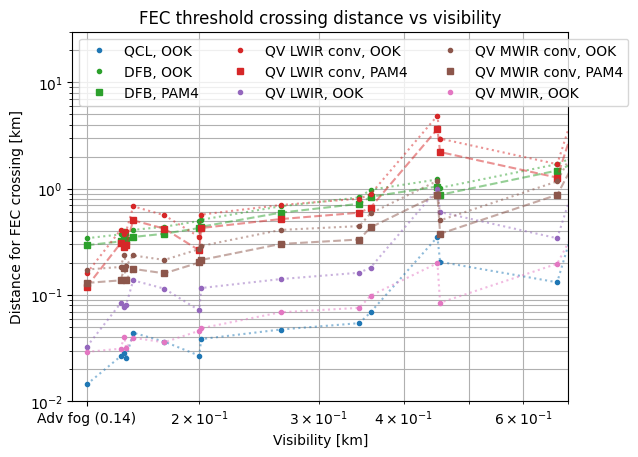

In [16]:
line_styles = ['dotted', 'dashed']
marker_styles = ['.','s']
marker_sizes = ['6','4']

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

plt.figure()
for i, com in enumerate(com_schemes_list):
    
    if np.max(com['FEC cross dist'])>1e-3:
        color = colors[int(i/2) % len(colors)]

        plt.plot(visibilities,com['FEC cross dist'],'.',label=com['type']+', '+com['scheme'],color=color, marker=marker_styles[i%2], markersize=marker_sizes[i%2])

        sorted_pairs = sorted(zip(visibilities, com['FEC cross dist']))
        x_sorted, y_sorted = zip(*sorted_pairs)


        plt.plot(x_sorted, y_sorted, label="_no_legend_", color=color, linestyle = line_styles[i%2], alpha=0.5)

plt.title(f'FEC threshold crossing distance vs visibility')

plt.ylabel('Distance for FEC crossing [km]')
plt.xlabel('Visibility [km]')
plt.grid(which='both')
plt.legend(loc='lower right')
plt.yscale('log')
plt.xscale('log')
# plt.ylim([1e-2,2e2])
# plt.xlim([0.1,1])

plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\com_formats_signal_distance_vs_visibility.svg")
plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\com_formats_signal_distance_vs_visibility.pdf")


cur_ticks = plt.xticks()[0]
new_tick = visibilities[-2] #Advection fog
all_ticks = np.append(cur_ticks,new_tick)
all_labels = [f"{t:g}" if t!=new_tick else "Adv fog (0.14)" for t in all_ticks]
plt.xticks(all_ticks,all_labels)

plt.ylim([1e-2,3e1])
plt.xlim([0.13,0.7])
plt.legend(loc='upper left',ncol=3)

plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\com_formats_signal_distance_vs_visibility_zoom.svg")
plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\com_formats_signal_distance_vs_visibility_zoom.pdf")



## Cloud droplet size comparison

Test how propagation loss changes with wavelength for individual cloud droplet radii: 1, 4, 7, 12, 20 µm.

1. **Single particle number**: the same particle number density is applied to each size, multiplied directly onto the Mie efficiency at that radius (no integration, since there is only one radius per size).
2. **Gaussian distribution**: the same Gaussian droplet size distribution (peak and width) is used for every size, only shifted so its mean sits at each of the sizes above. The extinction coefficient is then obtained via the same DSD integral used for the fog cases.

Units are arbitrary (particle numbers are illustrative, not measured) - the purpose is to compare the wavelength dependence *across* droplet sizes, not to give absolute loss values.

In [43]:
#Compare propagation losses for individual cloud droplet sizes (radii): 1, 4, 7, 12, 20 µm.
#q_ext computed above already spans wavelengths x radius (0.01-50µm, 1000 points), so we reuse it directly.

cloud_radii = np.array([1, 2, 4, 7, 12])  # µm

q_ext_arr = np.array(q_ext)  # shape (n_wavelengths, n_radii)

cloud_radii_idx = [np.abs(radius - r).argmin() for r in cloud_radii]


In [44]:
#Test 1: single reasonable particle number, same for all sizes, multiplied directly onto the Mie efficiency at that radius.
#No integration over a distribution here (it would be redundant for a single point) - just a direct evaluation, so we can compare the sizes on equal footing.

N_single = 100  # cm⁻³, arbitrary but the same for all sizes

extinction_single = {}
for r, idx in zip(cloud_radii, cloud_radii_idx):
    geometric_cross_section_µm2 = np.pi * radius[idx]**2
    extinction_single[r] = N_single * q_ext_arr[:, idx] * geometric_cross_section_µm2 * 1e-3  # km⁻¹, same unit convention as sf.mie_extinction_coefficient


Text(0.5, 1.0, 'Single particle number (N = 100 cm⁻³) per droplet size')

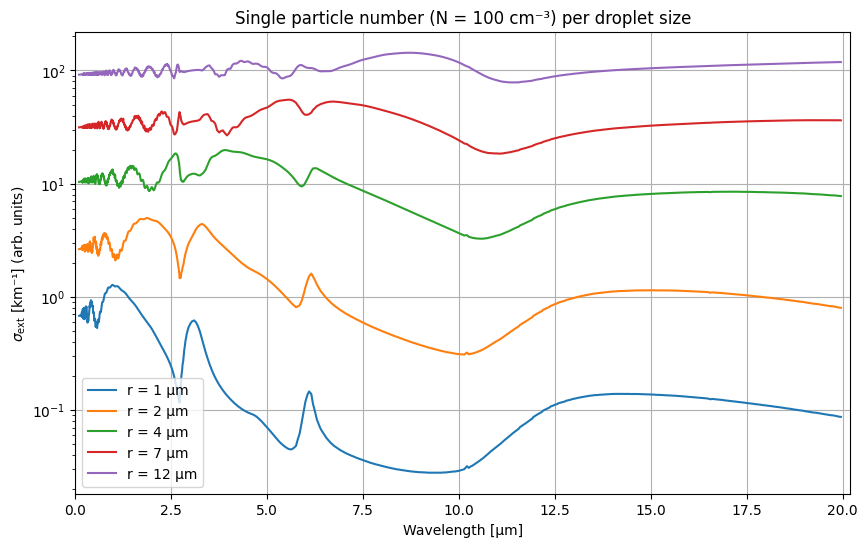

In [45]:
#Plot the resulting extinction coefficients vs wavelength, one curve per droplet size.

plt.figure(figsize=(10,6))
for r in cloud_radii:
    plt.plot(wavelengths, extinction_single[r], label=f"r = {r} µm")

plt.grid()
plt.legend()
plt.xlabel("Wavelength [µm]")
plt.ylabel(r"$\sigma_\mathrm{ext}$ [km⁻¹] (arb. units)")
plt.yscale('log')
plt.xlim(0,20.2)
plt.title(f"Single particle number (N = {N_single} cm⁻³) per droplet size")


In [46]:
#Test 2: same Gaussian droplet size distribution shape (fixed peak and width) for each size, only the mean radius is shifted to match cloud_radii.

gauss_sigma = 1.5  # µm, fixed width, same for all sizes
gauss_N0 = 100  # cm⁻³ µm⁻¹, arbitrary peak amplitude, same for all sizes

def gaussian_dsd(r_mean, sigma, N0, radius):
    return N0 * np.exp(-(radius - r_mean)**2 / (2 * sigma**2))

cloud_dsds = {r: gaussian_dsd(r, gauss_sigma, gauss_N0, radius) for r in cloud_radii}


Text(0.5, 1.0, 'Gaussian droplet size distributions (same shape, shifted mean)')

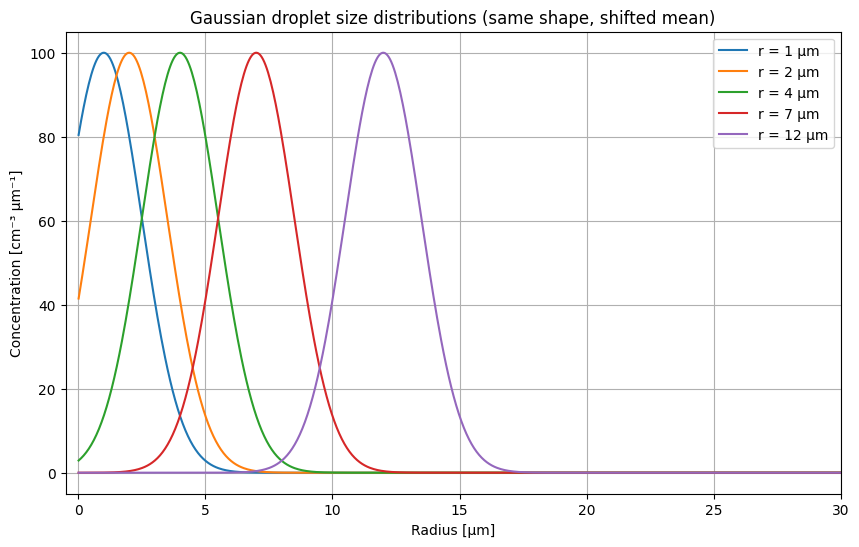

In [47]:
#Verify the DSDs have the same shape and are just shifted to each droplet size.

plt.figure(figsize=(10,6))
for r in cloud_radii:
    plt.plot(radius, cloud_dsds[r], label=f"r = {r} µm")

plt.grid()
plt.legend()
plt.xlabel("Radius [µm]")
plt.ylabel("Concentration [cm⁻³ µm⁻¹]")
plt.xlim(-0.5, 30)
plt.title("Gaussian droplet size distributions (same shape, shifted mean)")


In [48]:
#Integrate each Gaussian DSD against Q_ext(lambda,r) over radius (same integral as used for the fog cases above) to get the extinction coefficient per wavelength.

extinction_gauss = {
    r: np.array([sf.mie_extinction_coefficient(cloud_dsds[r], q_ext_arr[i], radius) for i in range(len(wavelengths))])
    for r in cloud_radii
}


Text(0.5, 1.0, 'Gaussian DSD (σ = 1.5 µm) per droplet size')

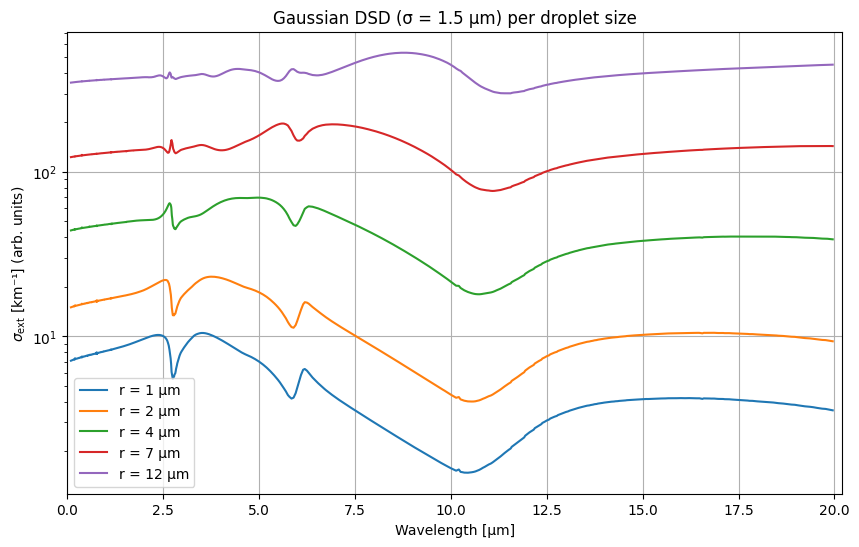

In [49]:
#Plot the resulting extinction coefficients vs wavelength, one curve per droplet size.

plt.figure(figsize=(10,6))
for r in cloud_radii:
    plt.plot(wavelengths, extinction_gauss[r], label=f"r = {r} µm")

plt.grid()
plt.legend()
plt.xlabel("Wavelength [µm]")
plt.ylabel(r"$\sigma_\mathrm{ext}$ [km⁻¹] (arb. units)")
plt.yscale('log')
plt.xlim(0,20.2)
plt.title(f"Gaussian DSD (σ = {gauss_sigma} µm) per droplet size")


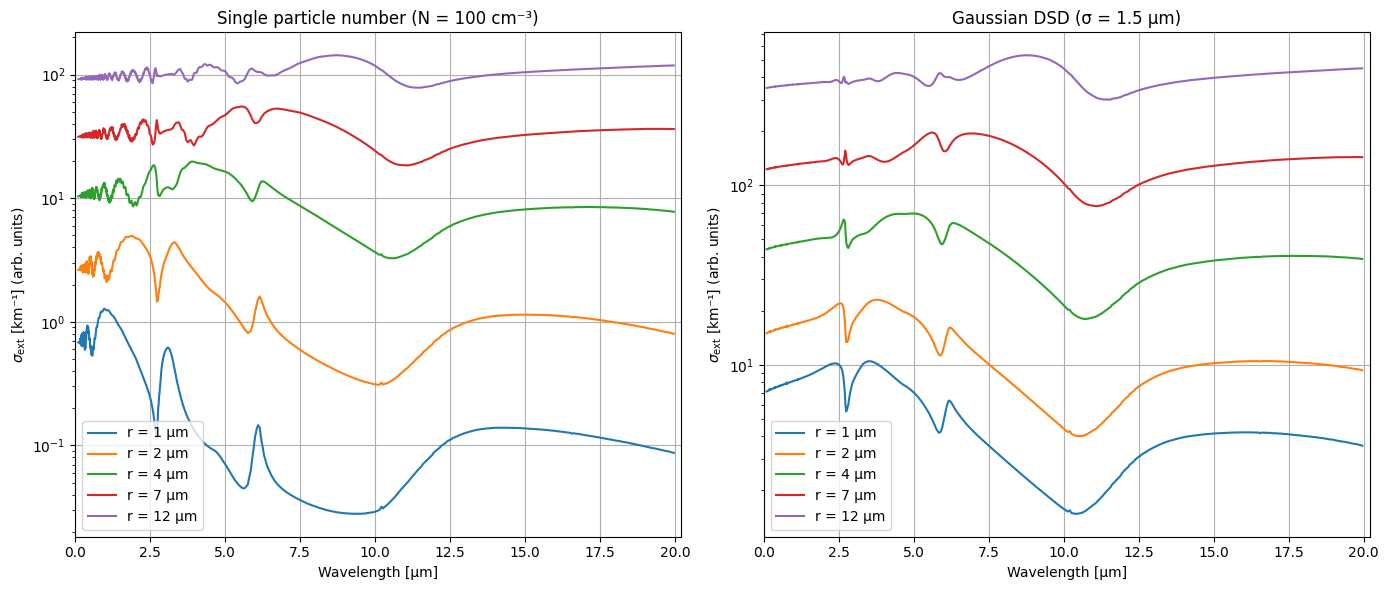

In [50]:
#Side-by-side comparison of the two methods for the cloud droplet sizes.

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for r in cloud_radii:
    axes[0].plot(wavelengths, extinction_single[r], label=f"r = {r} µm")
axes[0].set_title(f"Single particle number (N = {N_single} cm⁻³)")

for r in cloud_radii:
    axes[1].plot(wavelengths, extinction_gauss[r], label=f"r = {r} µm")
axes[1].set_title(f"Gaussian DSD (σ = {gauss_sigma} µm)")

for ax in axes:
    ax.grid()
    ax.legend()
    ax.set_xlabel("Wavelength [µm]")
    ax.set_ylabel(r"$\sigma_\mathrm{ext}$ [km⁻¹] (arb. units)")
    ax.set_yscale('log')
    ax.set_xlim(0,20.2)

plt.tight_layout()


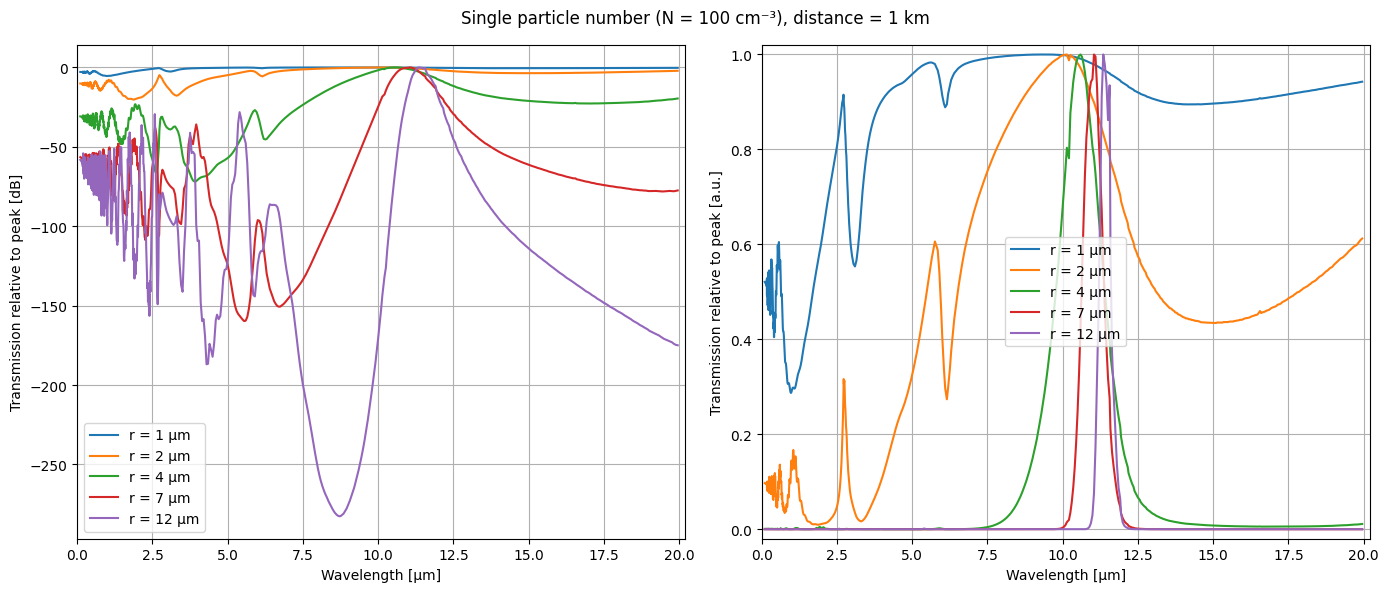

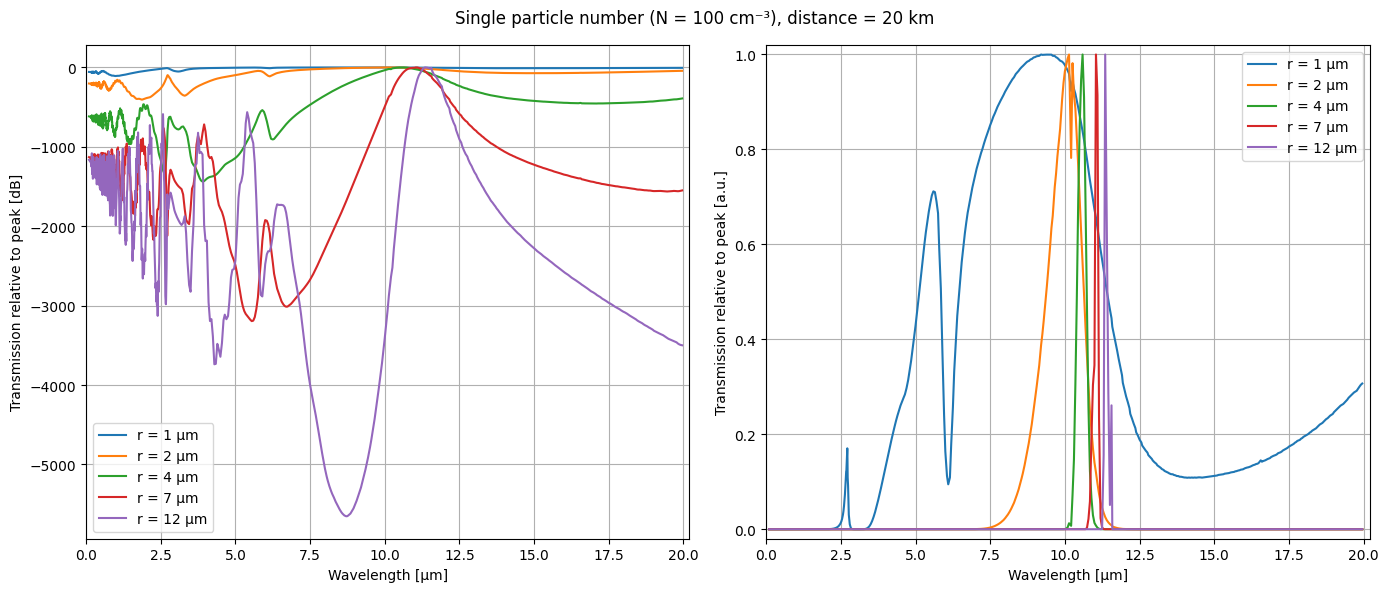

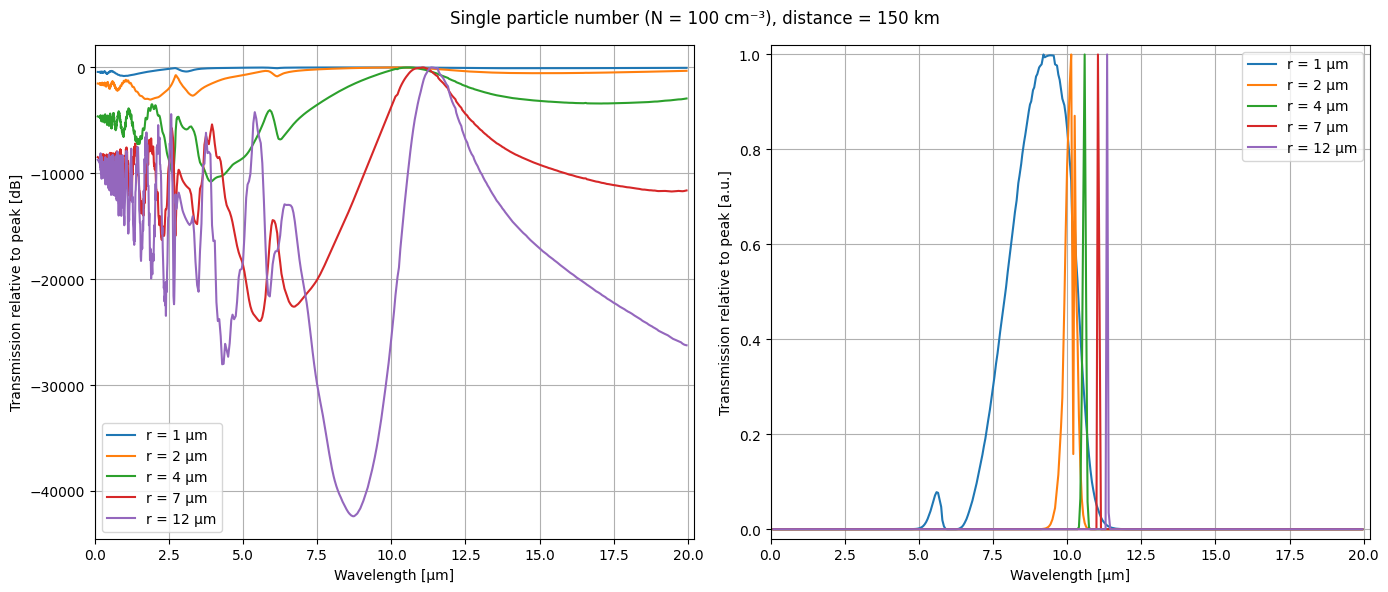

In [51]:
#Test 1 (single particle number): loss relative to each size's own peak-transmission wavelength, shown in dB and linear side by side, for each distance.
#log10(T) = -attenuation*distance/ln(10), computed directly (not via exp()/log10()) to avoid float64 underflow.
#dB and linear are just two views of the same quantity: rel_dB = 10*(log10_T - log10_T.max()), linear = 10**(rel_dB/10) - both peak at their size's best wavelength (0 dB / 1.0), dB keeps resolution far from the peak, linear stays bounded in [0,1].

loss_distances = [1, 20, 150]  # km

for dist in loss_distances:
    fig, (ax_dB, ax_lin) = plt.subplots(1, 2, figsize=(14,6))

    for r in cloud_radii:
        log10_T = -extinction_single[r] * dist / np.log(10)
        rel_dB = 10 * (log10_T - log10_T.max())

        ax_dB.plot(wavelengths, rel_dB, label=f"r = {r} µm")
        ax_lin.plot(wavelengths, 10**(rel_dB / 10), label=f"r = {r} µm")

    ax_dB.set_ylabel("Transmission relative to peak [dB]")
    ax_lin.set_ylabel("Transmission relative to peak [a.u.]")
    ax_lin.set_ylim(-0.02, 1.02)

    for ax in (ax_dB, ax_lin):
        ax.grid()
        ax.legend()
        ax.set_xlabel("Wavelength [µm]")
        ax.set_xlim(0, 20.2)

    fig.suptitle(f"Single particle number (N = {N_single} cm⁻³), distance = {dist} km")
    plt.tight_layout()


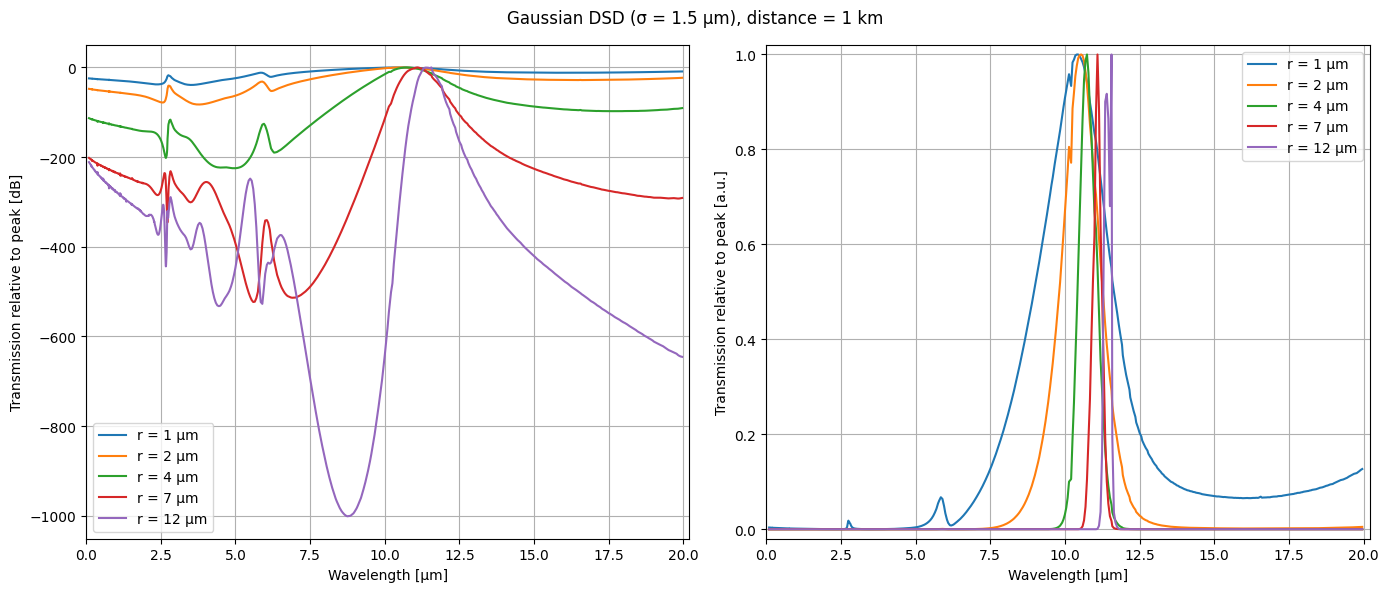

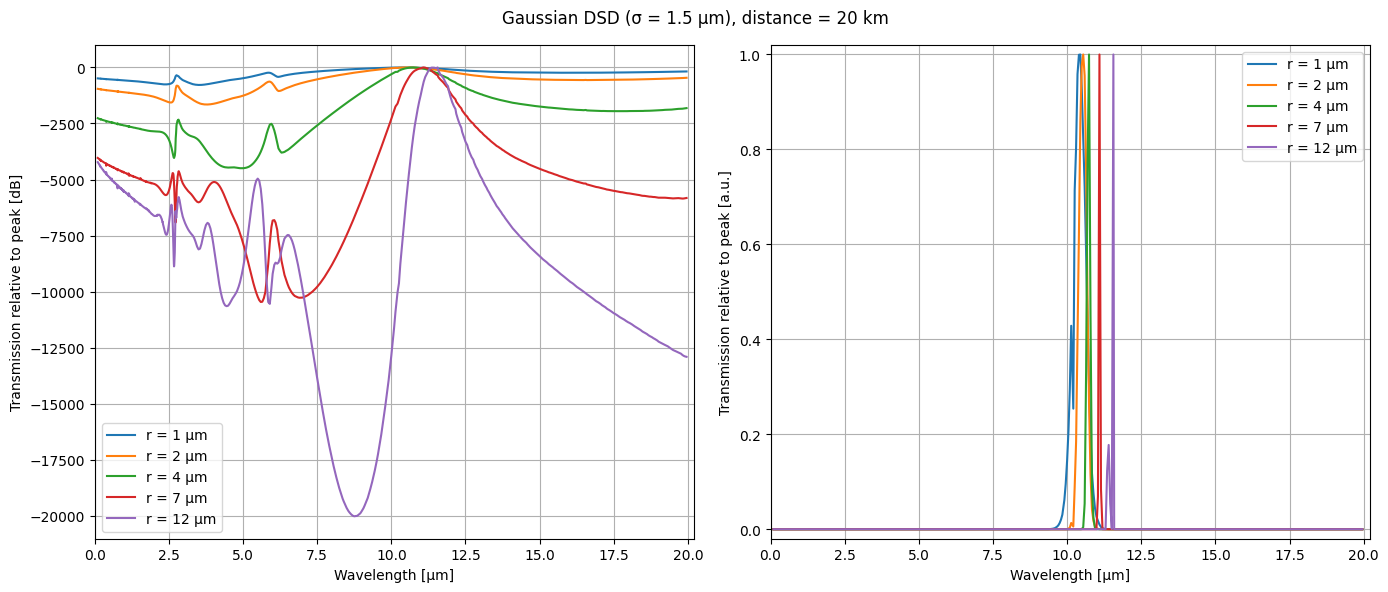

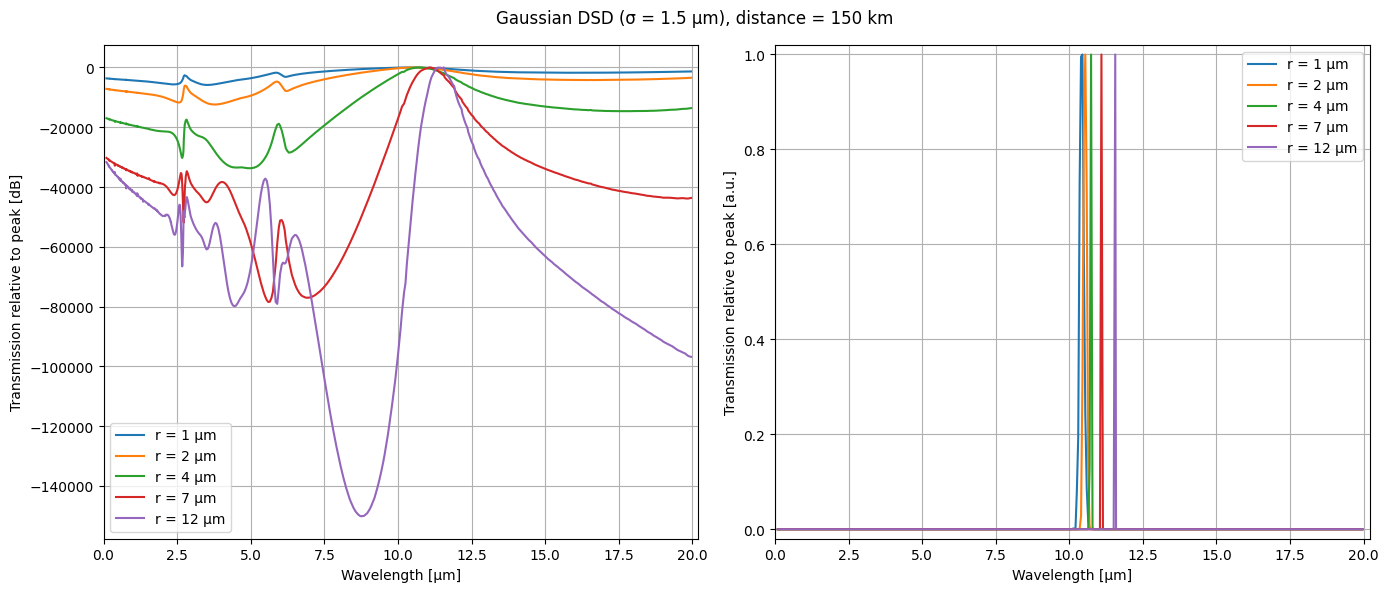

In [52]:
#Test 2 (Gaussian DSD): same dB/linear side-by-side plot as Test 1 above, using extinction_gauss instead.

for dist in loss_distances:
    fig, (ax_dB, ax_lin) = plt.subplots(1, 2, figsize=(14,6))

    for r in cloud_radii:
        log10_T = -extinction_gauss[r] * dist / np.log(10)
        rel_dB = 10 * (log10_T - log10_T.max())

        ax_dB.plot(wavelengths, rel_dB, label=f"r = {r} µm")
        ax_lin.plot(wavelengths, 10**(rel_dB / 10), label=f"r = {r} µm")

    ax_dB.set_ylabel("Transmission relative to peak [dB]")
    ax_lin.set_ylabel("Transmission relative to peak [a.u.]")
    ax_lin.set_ylim(-0.02, 1.02)

    for ax in (ax_dB, ax_lin):
        ax.grid()
        ax.legend()
        ax.set_xlabel("Wavelength [µm]")
        ax.set_xlim(0, 20.2)

    fig.suptitle(f"Gaussian DSD (σ = {gauss_sigma} µm), distance = {dist} km")
    plt.tight_layout()


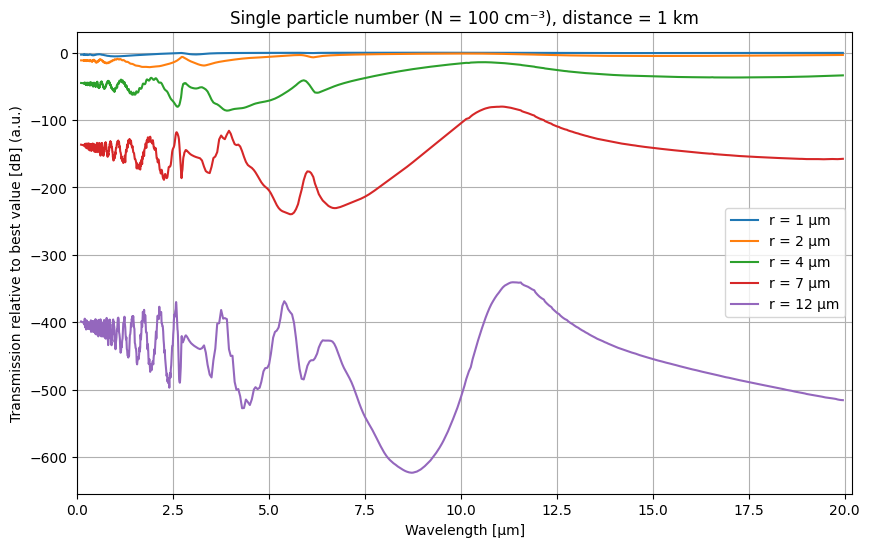

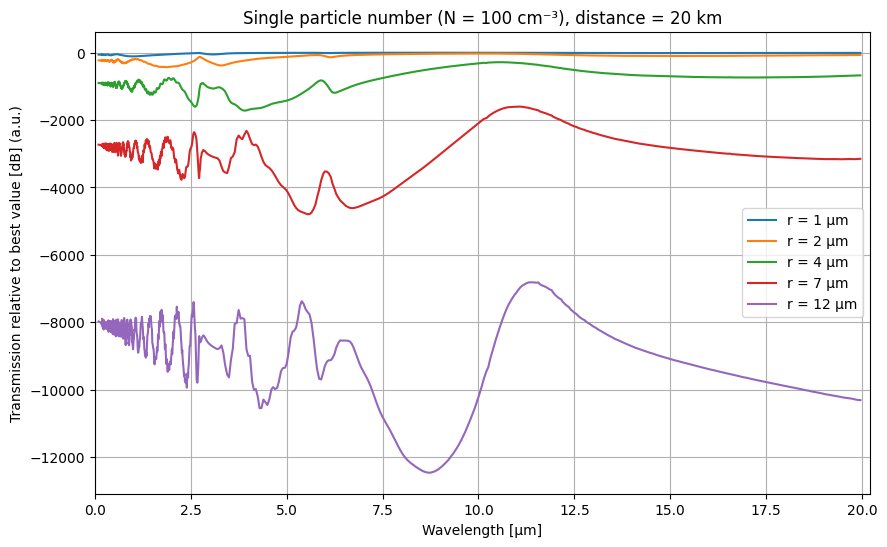

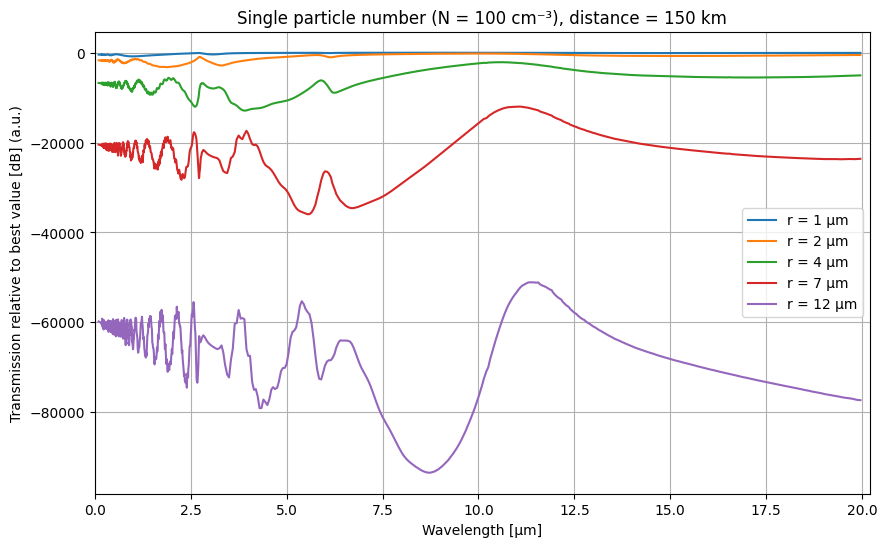

In [56]:
#Test 1: instead of normalizing each size to its own peak (which hides how much worse the larger sizes are overall), normalize all 5 sizes to ONE shared reference - the single best transmission achieved by any size at this distance.
#This shows the actual gap between sizes: whichever size reaches the reference sits at 0 dB at its best wavelength, the rest sit below it everywhere.
#Only makes sense in dB - in linear scale everything but the best size would underflow to 0 immediately, since we're no longer comparing each curve to its own achievable best.

for dist in loss_distances:
    log10_T_all = {r: -extinction_single[r] * dist / np.log(10) for r in cloud_radii}
    shared_ref = max(log10_T.max() for log10_T in log10_T_all.values())

    plt.figure(figsize=(10,6))
    for r in cloud_radii:
        plt.plot(wavelengths, 10 * (log10_T_all[r] - shared_ref), label=f"r = {r} µm")

    plt.grid()
    plt.legend()
    plt.xlabel("Wavelength [µm]")
    plt.ylabel("Transmission relative to best value [dB] (a.u.)")
    plt.xlim(0, 20.2)
    plt.title(f"Single particle number (N = {N_single} cm⁻³), distance = {dist} km")


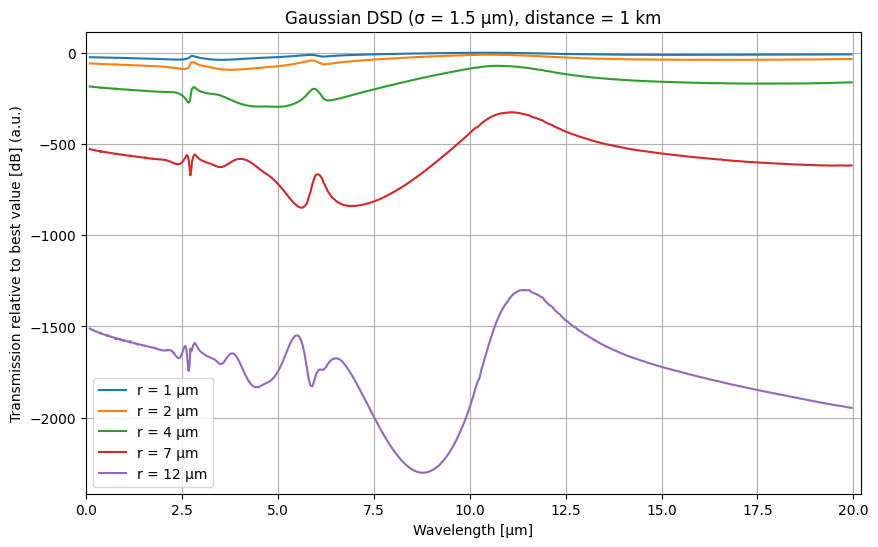

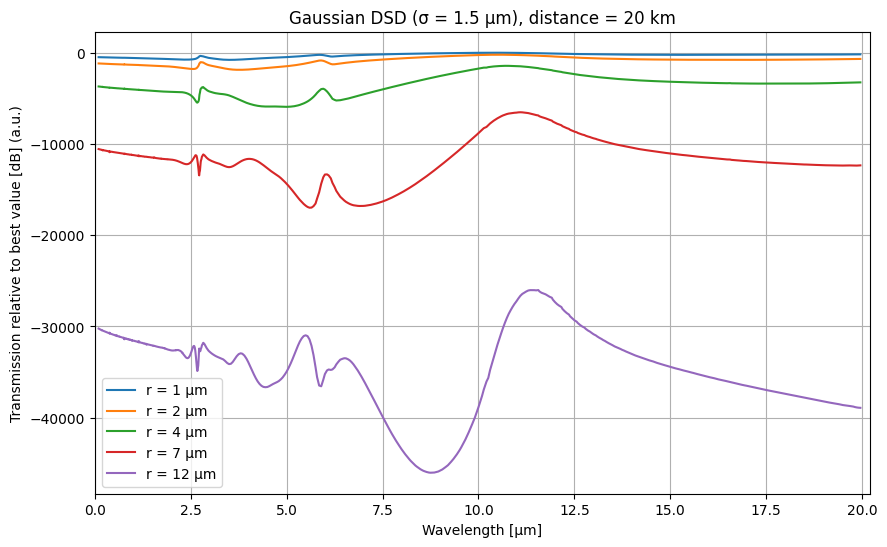

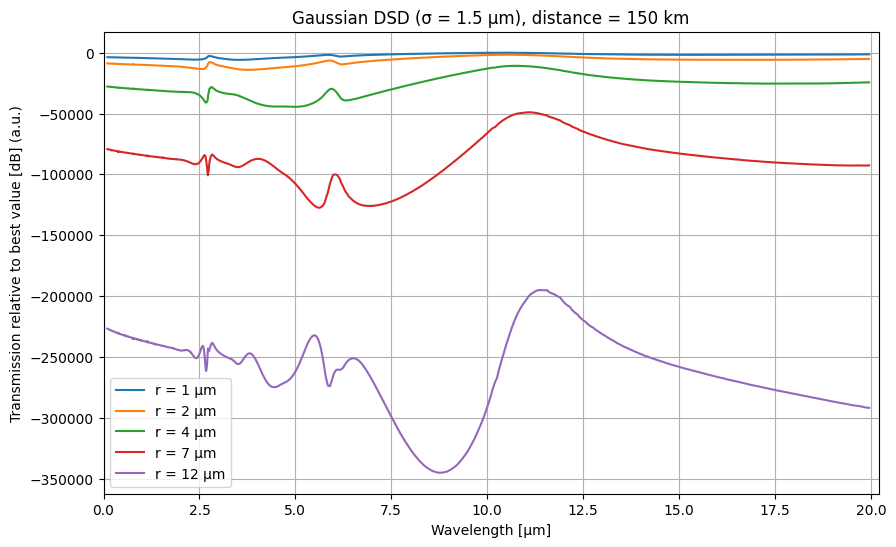

In [55]:
#Test 2: same shared-reference comparison as Test 1 above, using extinction_gauss.

for dist in loss_distances:
    log10_T_all = {r: -extinction_gauss[r] * dist / np.log(10) for r in cloud_radii}
    shared_ref = max(log10_T.max() for log10_T in log10_T_all.values())

    plt.figure(figsize=(10,6))
    for r in cloud_radii:
        plt.plot(wavelengths, 10 * (log10_T_all[r] - shared_ref), label=f"r = {r} µm")

    plt.grid()
    plt.legend()
    plt.xlabel("Wavelength [µm]")
    plt.ylabel("Transmission relative to best value [dB] (a.u.)")
    plt.xlim(0, 20.2)
    plt.title(f"Gaussian DSD (σ = {gauss_sigma} µm), distance = {dist} km")
